In [1]:
# ゲート付きRNN
# RNNの問題点
# RNNの復習
# 勾配消失、勾配爆発
# 勾配消失、勾配爆発の原因

In [6]:
# 逆伝播の際の勾配の値の変化
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()

N = 2 # ミニバッチサイズ
H = 3 # 隠れ状態ベクトルの次元数
T = 20 # 時系列データの長さ

dh = np.ones((N, H))
np.random.seed(3) # 再現性のため乱数のシードを固定
Wh = rng.random((H, H)) * 0.5

norm_list = []
for t in range(T):
    dh = dh @ Wh.T
    norm = np.sqrt(np.sum(dh**2)) / N
    norm_list.append(norm)

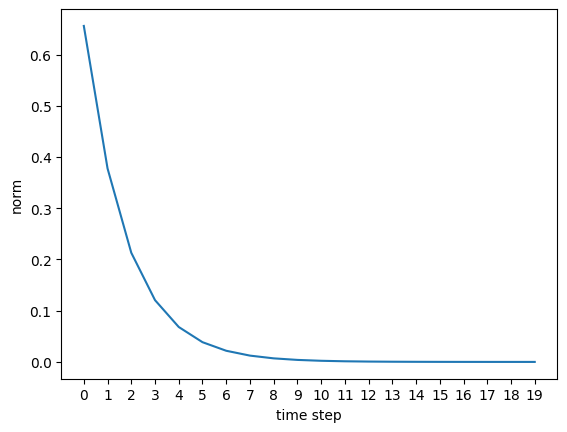

In [7]:
# グラフに表示してみる
plt.plot(np.arange(len(norm_list)), norm_list)
plt.xticks(np.arange(len(norm_list)))
plt.xlabel("time step")
plt.ylabel("norm")
plt.show()

In [10]:
# 勾配爆発への対策
# 勾配クリッピング
import numpy as np

rng = np.random.default_rng()

dW1 = rng.random((3, 3)) * 10
dW2 = rng.random((3, 3)) * 10
grads = [dW1, dW2]
max_norm = 5.0

def clip_grads(grads, max_norm):
    total_norm = 0
    for grad in grads:
        total_norm += np.sum(grad ** 2)
    total_norm = np.sqrt(total_norm)

    rate = max_norm / (total_norm + 1e-6)
    if rate < 1:
        for grad in grads:
            grad += rate

clip_grads(grads, max_norm)

In [11]:
# 勾配消失とLSTM
# LSTMのインタフェース
# LSTMレイヤの組み立て
# outputゲート
# forgetゲート
# 新しい記憶セル
# inputゲート
# LSTMの勾配の流れ


In [13]:
# LSTMの実装
import sys
sys.path.append("..")
from common.functions import sigmoid

class LSTM:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev, c_prev):
        Wx, Wh, b = self.params
        N, H = h_prev.shape

        A = x @ Wx + h_prev @ Wh + b

        # slice
        f = A[:, :H]
        g = A[:, H:2*H]
        i = A[:, 2*H:3*H]
        o = A[:, 3*H:]

        f = sigmoid(f)
        g = np.tanh(g)
        i = sigmoid(i)
        o = sigmoid(o)

        c_next = f * c_prev + g * i
        h_next = o * np.tanh(c_next)

        self.cache = (x, h_prev, c_prev, i, f, g, o, c_next)
        return h_next, c_next

In [14]:
# Time RNNの実装
class TimeLSTM:
    def __init__(self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None

        self.h, self.c = None, None
        self.dh = None
        self.stateful = stateful

    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, D = xs.shape
        H = Wh.shape[0]

        self.layers = []
        hs = np.empty((N, T, H), dtype="f")

        if not self.stateful or self.h is None:
            self.h = np.zeros((N, H), dtype="f")
        if not self.stateful or self.c is None:
            self.c = np.zeros((N, H), dtype="f")

        for t in range(T):
            layer = LSTM(*self.params)
            self.h, self.c = layer.forward(xs[:, t, :], self.h, self.c)


            self.layers.append(layer)

        return hs

    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D = Wx.shape[0]

        dxs = np.empty((N, T, D), dtype="f")
        dh, dc = 0, 0

        grads = [0, 0, 0]
        for t in reversed(range(T)):
            layer = self.layers[t]
            dx, dh, dc = layer.backward(dhs[:, t, :] + dh, dc)
            dxs[:, t, :] = dx
            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
            self.dh = dh
            return dxs

    def set_state(self, h, c=None):
        self.h, self.c = h, c

    def reset_state(self):
        self.h, self.c = None, None

        

In [22]:
# LSTMを使った言語モデル
# Rnnlmクラスの実装
import sys
sys.path.append("..")
from common.time_layers import *
import pickle

rng = np.random.default_rng()

class Rnnlm:
    def __init__(self, vocab_size=10000, wordvec_size=100, hidden_size=100):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = rng.random()

        # 重みの初期化
        embed_W = (rn(V, D) / 100).astype("f")
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype("f")
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype("f")
        lstm_b = np.zeros(4 * H).astype("f")
        affine_W = (rn(H, V) / np.sqrt(H)).astype("f")
        affine_b = np.zeros(V).astype("f")

        # レイヤの生成
        self.layers = [
            TimeEmbedding(embed_W),
            TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.lstm_layer = self.layers[1]

        # 全ての重みと勾配をリストにまとめる
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

        
    def predict(self, xs):
        for layer in self.layers:
            xs = layer.forward(xs)
        return xs

    def forward(self, xs, ts):
        score = self.predict(xs)
        loss = self.loss_layer.forward(score, ts)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        self.lstm_layer.reset_state()

    def save_params(self, file_name="Rnnlm.pkl"):
        with open(file_name, "rb") as f:
            self.params = pickle.load(f)

| epoch 1 |  iter 1 / 1327 | time 0[s] | perplexity 10001.96
| epoch 1 |  iter 21 / 1327 | time 2[s] | perplexity 2884.52
| epoch 1 |  iter 41 / 1327 | time 5[s] | perplexity 1241.06
| epoch 1 |  iter 61 / 1327 | time 8[s] | perplexity 957.41
| epoch 1 |  iter 81 / 1327 | time 11[s] | perplexity 764.44
| epoch 1 |  iter 101 / 1327 | time 14[s] | perplexity 670.60
| epoch 1 |  iter 121 / 1327 | time 17[s] | perplexity 637.44
| epoch 1 |  iter 141 / 1327 | time 19[s] | perplexity 597.04
| epoch 1 |  iter 161 / 1327 | time 22[s] | perplexity 576.44
| epoch 1 |  iter 181 / 1327 | time 25[s] | perplexity 576.05
| epoch 1 |  iter 201 / 1327 | time 28[s] | perplexity 507.51
| epoch 1 |  iter 221 / 1327 | time 31[s] | perplexity 492.45
| epoch 1 |  iter 241 / 1327 | time 34[s] | perplexity 436.13
| epoch 1 |  iter 261 / 1327 | time 36[s] | perplexity 464.63
| epoch 1 |  iter 281 / 1327 | time 39[s] | perplexity 447.62
| epoch 1 |  iter 301 / 1327 | time 42[s] | perplexity 389.89
| epoch 1 |  i

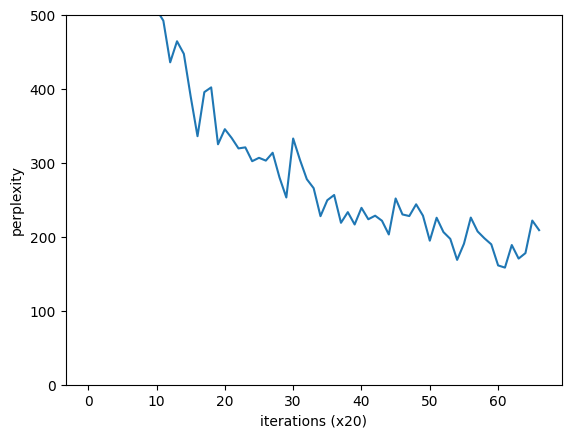

evaluating perplexity ...
234 / 235
test property:  197.76994495798226


In [23]:
# PTBデータセットの学習
import sys
sys.path.append("..")
from common.optimizer import SGD
from common.trainer import RnnlmTrainer
from common.util import eval_perplexity
from dataset import ptb
from rnnlm import Rnnlm

# ハイパーパラメータの設定
batch_size = 20
wordvec_size = 100
hidden_size = 100
time_size = 35
lr = 20.0
max_epoch = 1
max_grad = 0.25

# 学習データの読み込み
corpus, word_to_id, id_to_word = ptb.load_data("train")
corpus_test, _, _ = ptb.load_data("test")
vocab_size = len(word_to_id)
xs = corpus[:-1]
ts = corpus[1:]

# モデルの生成
model = Rnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)
trainer = RnnlmTrainer(model, optimizer)

# 勾配クリッピングを適用して学習
trainer.fit(xs, ts, max_epoch, batch_size, time_size, max_grad, eval_interval=20)
trainer.plot(ylim=(0, 500))

# テストデータで評価
model.reset_state()
ppl_test = eval_perplexity(model, corpus_test)
print("test property: ", ppl_test)

# パラメータの保存
model.save_params()

In [24]:
# RNNLMのさらなる改善
# LSTMレイヤの多層化
# Dropoutによる過学習の抑制
# 重み共有

In [26]:
# より良いRNNLMの実装
import sys
sys.path.append("..")
from common.time_layers import *
from common.np import * 
from common.base_model import BaseModel

rng = np.random.default_rng()

class BetterRnnlm(BaseModel):
    def __init__(self, vocab_size=10000, wordvec_size=650, hidden_size=650, dropout_ratio=0.5):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = rng.random()

        embed_W = (rn(V, D) / 100).astype("f")
        lstm_Wx1 = (rn(D, 4 * H) / np.sqrt(D)).astype("f")
        lstm_Wh1 = (rn(H, 4 * H) / np.sqrt(H)).astype("f")
        lstm_b1 = np.zeros(4 * H).astype("f")
        lstm_Wx2 = (rn(H, 4 * H) / np.sqrt(H)).astype("f")
        lstm_Wh2 = (rn(H, 4 * H) / np.sqrt(H)).astype("f")
        lstm_b2 = np.zeros(4 * H).astype("f")
        affine_b = np.zeros(V).astype("f")

        # 3つの改善
        self.layers = [
            TimeEmbedding(embed_W),
            TimeDropout(dropout_ratio),
            TimeLSTM(lstm_Wx1, lstm_Wh1, lstm_b1, stateful=True),
            TimeDropout(dropout_ratio),
            TimeLSTM(lstm_Wx2, lstm_Wh2, lstm_b2, stateful=True),
            TimeDropout(dropout_ratio),
            TimeAffine(embed_W.T, affine_b) # 重み共有
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.lstm_layers = [self.layers[2], self.layers[4]]
        self.drop_layers = [self.layers[1], self.layers[3], self.layers[5]]
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, xs, train_fig=False):
        for layer in self.drop_layers:
            layer.train_fig = train_fig
        for layer in self.layers:
            xs = layer.forward(xs)
        return xs

    def forward(self, xs, ts, train_fig=True):
        score = self.predict(xs, train_fig)
        loss = self.loss_layer.forward(score, ts)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        for layer in self.lstm_layers:
            layer.reset_state()


In [ ]:
# 学習用のコード
import sys
sys.path.append("..")
from common import config
from common.optimizer import SGD
from common.trainer import RnnlmTrainer
from common.util import eval_perplexity
from dataset import ptb
from better_rnnlm import BetterRnnlm

# ハイパーパラメータの設定
batch_size = 20
wordvec_size = 650
hidden_size = 650
time_size = 35
lr = 20.0
max_epoch = 1
max_grad = 0.25
dropout = 0.5

# 学習データの読み込み
corpus, word_to_id, id_to_word = ptb.load_data("train")
corpus_val, _, _ = ptb.load_data("val")
corpus_test, _, _ = ptb.load_data("test")

vocab_size = len(word_to_id)
xs = corpus[:-1]
ts = corpus[1:]

model = BetterRnnlm(vocab_size, wordvec_size, hidden_size, dropout)
optimizer = SGD(lr)
trainer = RnnlmTrainer(model, optimizer)

best_ppl = float("inf")
for epoch in range(max_epoch):
    trainer.fit(xs, ts, max_epoch=1, batch_size=batch_size,
                time_size=time_size, max_grad=max_grad)


    model.reset_state()
    ppl = eval_perplexity(model, corpus_val)
    print("valid perplexity:", ppl)
    
    if best_ppl > ppl:
        best_ppl = ppl
        model.save_params()
    else:
        lr /= 4.0
        optimizer.lr = lr
        model.reset_state()
        print("." * 50)

In [ ]:
# 最先端の研究へ